# SOH Class 예측 AI모델 개발

## 개요
- 리튬이온 배터리의 건강상태(State-of-health: SOH)의 등급(Class) 추정 AI모델 개발

## 분석배경 
- 리튬이온 배터리는 충/방전 동작 및 저장 환경에 따라 전극 노화 및 반응 가능한 리튬이온의 감소로 사용 가능한 용량이 감소합니다.
- 사용 가능한 용량의 감소는 리튬이온 배터리가 사용되는 어플리케이션(전기자동차, 에너지저장장치 등)의 사용 시간을 감소시키는 매우 중요한 모니터링 인자로, 이를 건강상태(State-of-health: SOH)라고 합니다.
- 하지만, 리튬이온 배터리의 사용에 따른 노화를 추정하기 위해서는 비선형적인 배터리의 동작 특성에 따른 지표 선정과 이를 효율적으로 반영할 수 있는 분석 방법이 필요하며 
- 이를 바탕으로 리튬이온 배터리의 건강상태(State-of-health: SOH)의 등급(Class)을 추정하여 분류할 수 있는 AI 모델을 개발하고자 합니다.

## 평가 지표
- accuracy (정확도)

## 데이터 셋 정보

### [Data Files]
- train.csv: 학습용 데이터 (Features, Target) - 50,000건 
- test.csv:  예측용 데이터 (Features) - 50,000건

### [Feature]
- V0 ~ V7

### [Target]
- Class: 리튬이온 배터리의 건강상태 (0~4)

## 분석단계 
- **[step1] 라이브러리 및 데이터 불러오기**
 - (1) 라이브러리 불러오기
 - (2) 데이터 불러오기 
 - (3) 데이터 확인  
- **[step2] 탐색적 데이터 분석 (EDA)**
 - (1) 기술적 통계분석
 - (2) 변수별 분포 시각화  
- **[step3] 데이터 전처리**
 - (1) 중복값 처리 **(Train셋만)**
 - (2) 불필요한 Feature삭제 (ID 등)
 - (3) 결측치 처리 
 - (4) 아웃라이어 제거 **(Train셋만 & 양적변수만)**
 - (5) Feature, Target 설정
 - (6) 원핫 인코딩 **(feature-질적변수만)**
 - (7) 스케일링 **(feature-양적변수만)**
- **[step4] 모델 설계**
 - (1) 훈련 및 검증 데이터 분할
 - (2) 평가지표 확인
 - (3) 알고리즘별 학습, 예측, 평가
 - (4) 하이퍼 파라미터 튜닝
- **[step5] 모델 선택 및 적용**
 - (1) test data의 예측값 생성
- **[step6] 결과 파일 생성**
 - (1) 예시 파일 불러오기 
 - (2) test data의 예측 결과 저장 
 - (3) 제출할 csv파일 생성

## [Step1] 불러오기

### (1) 라이브러리 불러오기

In [ ]:
# 데이터분석 라이브러리 불러오기
<blank> pandas as pd            # 판다스
import <blank> as np           # 넘파이

#시각화를 위한 라이브러리 불러오기 
import matplotlib.pyplot as plt  # 맷플라립.파이플랏
import <blank>  as sns           # 시본

In [ ]:
#AI모델 사용을 위한 라이브러리 불러오기
from sklearn.linear_model import <blank> #LogisticRegression
from sklearn.neighbors  import <blank>   #KNeighborsClassifier 
from sklearn.tree import <blank>         #DecisionTreeClassifier

from sklearn.ensemble import <blank>     #RandomForestClassifier 
from sklearn.ensemble import <blank>     #ExtraTreesClassifier 

from xgboost import <blank>              #XGBClassifier 
from lightgbm import <blank>             #LGBMClassifier

#모델링을 위한 함수 불러오기 
from sklearn.model_selection import <blank> #train_test_split
from sklearn.metrics import <blank>         #accuracy_score

#future warning filter 불러오기
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### (2) 데이터 불러오기
**train data**

In [ ]:
train = pd.read_csv('./train.csv')

In [ ]:
train.head()

**test data**

In [ ]:
test = pd.<blank>('./test.csv')

In [ ]:
# test data 확인
test.head()

### (3) 데이터 확인 
 - df.info()

In [ ]:
train.info()

In [ ]:
test.<blank>

## [Step2] 탐색적 데이터 분석 (EDA)

### (1) 기술통계분석
- describe()를 이용한 통계치 확인

In [ ]:
train.<blank>

In [ ]:
test.<blank>

### (2) 변수별 분포 시각화 
#### 1) 두 변수간 상관관계를 보여주는 pairplot

In [ ]:
plt.figure(figsize = (15,15))
sns.<blank>(train) 

plt.show()

**[정리] 변수들간 선형관계가 없는 것을 확인할 수 있다**

#### 2) 연속형 (양적) 변수의 분포를 보여주는 histplot 
- V0~V7

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20,10))

sns.<blank>(x = train['V0'], ax=axes[0][0])
#완성해 봅시다.

plt.show()

#### 3) 범주형 (질적) 변수의 빈도를 보여주는 countplot
- Class(target)

In [ ]:
#완성해 봅시다.


 - Class의 경우에는 큰 불균형 없음

## [step3] 데이터 전처리

### (1) 중복값 처리 **(Train셋만)**

In [ ]:
# train 셋의 중복값 확인
train.<blank>.<blank>

##### [주의1]
- 만약 train data 에 중복값이 있다면?
    - df.drop_duplicates()를 이용하여 중복행을 제거
    - 회귀 파트에서 다룰 예정
    
##### [주의2]
- test 셋의 경우 예측 후 제출 파일과 데이터 건수가 동일해야 함
- 따라서 **test 셋에 대해서는 중복에 의한 제거처리를 하지 않음**

### (2) 불필요한 Feature 삭제

In [ ]:
# ID column 삭제 -train set


In [ ]:
# ID column 삭제 -test set


### (3) 결측치 처리

In [ ]:
# train data의 결측치 확인 



In [ ]:
# test data의 결측치 확인 



- 만약 train['Class'], 즉 **target 에 결측**이 있다면?
    - 이는 평균으로 대체할 대상이 아님
    - 해당 행을 미리 제거해야 함

In [ ]:
train['Class'].notnull()

In [ ]:
#train['Class']이 결측인 행 제거
train=train[<blnak>]
train

- train- **Feature**의 결측치를 각 변수의 평균치로 대체
 - df.fillna()
 - df.mean() 

In [ ]:
#train 셋의 결측치를 train 셋의 변수별 평균을 이용하여 대체 
train=train.fillna(train.mean())

- [주의] test 셋의 결측치도 **train 셋** 각 변수의 평균치로 대체합니다!

In [ ]:
#test 셋의 결측치를 train 셋의 변수별 평균을 이용하여 대체
test=test.fillna(<blank>)

- 결측치 처리가 되었음을 확인

In [ ]:
# train data 결측치 대체 완료 확인 




In [ ]:
# test data 결측치 대체 완료 확인 



### (4) 아웃라이어 제거 **(Train셋 & 양적변수만)**
- **[데이터셋]**
    - **train셋** 에 적용
    - train셋은 모델이 일반화된 패턴을 배우는 구간, 아웃라이어가 모델 학습에 악영향을 줄 수 있기 때문에 **아웃라이어 제거**
    - test셋은 모델의 성능을 평가하기 위한 처음 접하는(unseen) 데이터, **test 데이터는 손대지 않음**
- **[대상 변수]** 
    - **target** 아웃라이어 처리
        - 회귀모델에서 target의 극단적인 값은 모델 왜곡 가능, 예측 성능에 큰 영향
    - **feature** 아웃라이어 처리
        - feature 아웃라이어도 모델 학습에 영향 가능(특히 **target과 강한 상관관계** 때)
        - 하지만, 모든 feature를 다 아웃라이어 처리하다보면 데이터 유실이 심해짐
        - **일단 모델링을 하고 feature importance 뽑아서 후처리**도 전략 
            - 영향력 높은 feature만 따로 아웃라이어 처리
- **[아웃라이어 제거 순위]**
  - train셋의 target(1순위, **회귀모델**일 경우)
  - train셋의 feature(2순위)
  - 단, 변수의 아웃라이어가 자연스러운 변동일 경우에는 제거하지 않는 것이 좋으므로 신중하게 수행

In [ ]:
# 분류모델이므로 train셋의 feature를 대상으로 아웃라이어 확인 - boxplotting
sns.<blank>(data=train[["V0","V1","V3","V4","V5","V6","V7"]])
plt.show()

In [ ]:
#'V0'에서 상단 아웃라이어 제거 -  train['V0']<=1.5 인 데이터만 남김
train=train[train['V0']<=1.5]
train   # 50,000개 --> ??

### (5) Feature, Target 설정
- train 셋: Feature / Target 으로 분리
- test 셋: Feature만 설정

In [ ]:
# train set - features 설정
Xtrain=<blank>
Xtrain

In [ ]:
# train set - target 설정
ytrain=<blank>
ytrain

In [ ]:
# test set - features
Xtest=test.copy()
Xtest

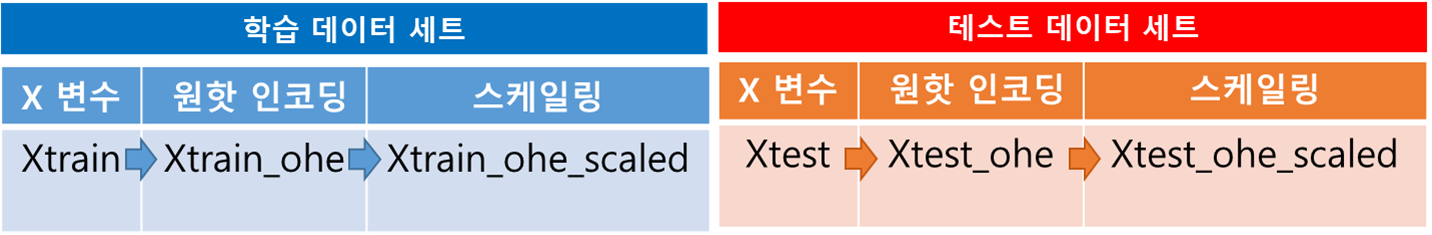

### (6) 원핫 인코딩 **(feature-질적변수만)**
- get_dummies(df, columns=[해당 column명])
- **feature** 중 **카테고리 변수**에 대해서 수행 
- 하지만 본 프로젝트에서는 feature에 카테고리 변수가 없으므로 이 과정을 생략

In [ ]:
# 본 프로젝트에서는 필요없는 과정이나 향후 원핫인코딩이 필요한 분류문제를 위해 이 과정을 남겨둠
# 현재는 원핫인코딩이 필요없으므로 기존 df을 단순 복사만 해둠
#실제 필요시 처리과정은 회귀파트에 다룰 예정
Xtrain_ohe=Xtrain.copy()  
Xtest_ohe=Xtest.copy()  

### (7) 스케일링 **(feature-양적변수만)**
- 스케일링을 통해 변수들의 데이터 분포나 범위를 조정

**[주의] 스케일링 시 주의사항**
- fit (스케일링을 위한 계산 수행): train data
- transform(적용): train data & test data 

**train data**
###### 1) MinMaxScaling
- 스케일후df= minmax_scaler.**fit_transform**(스케일전df)

###### 2) StandardScaling
- 스케일후df= standard_scaler.**fit_transform**(스케일전df)

In [ ]:
from sklearn.<blank> import StandardScaler

#object 선언
standard_scaler =  <blank>

In [ ]:
# 결과 DF를 미리 생성
Xtrain_ohe_scaled=Xtrain_ohe.copy()

# 스케일링이 필요한 변수만 나열
Xtrain_ohe_scaled[['V0','V1','V2','V3','V4','V5','V6','V7']]=standard_scaler.fit_transform(Xtrain_ohe[['V0','V1','V2','V3','V4','V5','V6','V7']])
Xtrain_ohe_scaled  #스케일링 결과 확인

In [ ]:
Xtrain_ohe_scaled.mean()

In [ ]:
Xtrain_ohe_scaled.var()

**test data**
###### 1) MinMaxScaling
- 스케일후df= minmax_scaler.**transform**(스케일전df)

###### 2) StandardScaling
- 스케일후df= standard_scaler.**transform**(스케일전df)

In [ ]:
# test 셋의 결과 DF 미리 생성
Xtest_ohe_scaled = <blank>


In [ ]:
Xtest_ohe_scaled[['V0','V1','V2','V3','V4','V5','V6','V7']]=standard_scaler.<blank>(Xtest_ohe[['V0','V1','V2','V3','V4','V5','V6','V7']])
Xtest_ohe_scaled  #스케일링 결과 확인

In [ ]:
Xtest_ohe_scaled.mean()

In [ ]:
Xtest_ohe_scaled.var()

## [step4] 모델 설계 
 - 모델의 선택 및 학습, 예측, 평가 분석 모델 설계
 - 다양한 모델의 성능비교 실시 
  - LogisticRegression, DecisionTree, KNN 
  - 트리기반 모델 중 배깅 기법을 적용한 Random Forest, ExtraTree, 
  - 트리기반 모델 중 부스팅 기법을 적용한 XGBoost와 Light GBM 
 

### Test vs. Validation dataset 나누기
- 성능을 평가하기 위해 학습 데이터셋에서 20%를 활용해 검증 데이터셋을 만듭니다
 - test_size = 0.2
 - random_state = 10

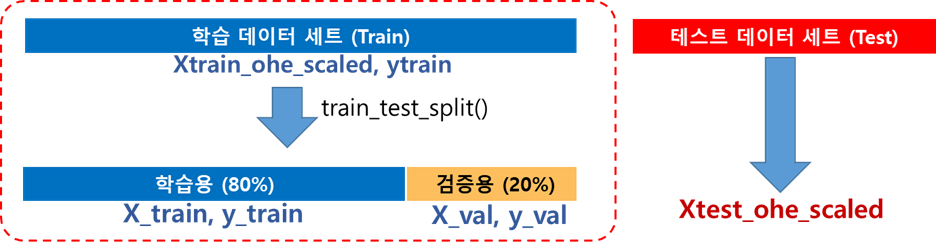

### (1) 훈련 및 검증 데이터 분할

In [ ]:
# 데이터 분할: test_size=0.2, random_state=10

X_train, X_val, y_train, y_val = train_test_split(<blank>, <blank>, test_size=0.2, random_state=10)

### (2) 평가지표 확인
- 평가지표가 accuracy이므로 skleran의 accuracy_score() 함수 사용

### (3) 알고리즘별 학습, 예측, 평가 실시 

#### 1) Logistic Regression

In [ ]:
#객체생성
lr=LogisticRegression()   

#학습 
lr.fit(X_train, y_train)

#예측
lr_pred = lr.predict(X_val)

#평가 
print('Logistic Regression 모델의 정확도 : ', accuracy_score(y_val, lr_pred))

#### 2) KNeighbors Classifier

#### 3) Decision Tree Classifier

#### 4) Random Forest Classifier

#### 5) Extra Tree Classifier

#### 6) XGBoost 

#### 7) light GBM

In [ ]:
# 참고1
a=[1,2,3]
for i in a:
    #i=1,2,3
    print(i)

In [ ]:
# 참고2
a=[LogisticRegression(), DecisionTreeClassifier()]
for i in a:
    #i=LogisticRegression(),DecisionTreeClassifier()
    print(i)

In [ ]:
# 참고3   dictionary
a={ 'A': 1,
    'B': 2,
    'C': 3 }   

In [ ]:
a.keys()

In [ ]:
a.values()

In [ ]:
a.items()

- 반복 작업을 for문으로 처리!

In [ ]:
models = {    
    'LogisticRegression': LogisticRegression(),
    'KNN':KNeighborsClassifier(),
    'Decision Tree Classifier': DecisionTreeClassifier(),
    'XGB Classifier' : XGBClassifier(verbose=-1,n_jobs=-1),
    'LGBM Classifier' : LGBMClassifier(verbose=-1,n_jobs=-1),
    'Random Forest Classifier': RandomForestClassifier(n_jobs=-1),
    'Extra Trees Classifier': ExtraTreesClassifier(n_jobs=-1)
}

In [ ]:
# 모델 학습 및 평가
for name, estimator in models.items():     
    <blank>.fit(X_train, y_train)
    pred = <blank>.predict(X_val)
    score = accuracy_score(y_val, pred)
    print(f'[{name} 모델의 accuracy ]: {round(score, 4)}')

- 최적의 모델을 어떻게 기억해야 할까?

In [ ]:
# 초기화: selected_estimator, max_score
selected_estimator = None
max_score = <blank>

In [ ]:
# 모델 학습 및 평가
for name, estimator in models.items():
    estimator.fit(X_train, y_train)
    pred = estimator.predict(X_val)
    score = accuracy_score(y_val, pred)
    print(f'[{name} 모델의 accuracy ]: {round(score, 4)}')

    if score > max_score:
        selected_estimator = estimator
        max_score = score
        print('selected estimator: {}'.format(name))
    print('')

**[정리] 가장 정확도가 높은 모델을 사용하기로 결정** 
- https://xgboost.readthedocs.io/en/stable/parameter.html
- https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html

### (4) 하이퍼 파라미터 튜닝
- 검증 데이터셋을 이용한 평가에서 가장 좋은 성능을 보인 모델의 하이퍼 파라미터 튜닝
- 3개의 파라미터 **(max_depth, learning_rate, n_estimators)** 튜닝

- 튜닝전에, default parameter일때의 성능을 Cross Validation 기반 재검증

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1) (Cross Validation이 목적이므로) 파라미터 설정은 하지 않음
parameters =<blank>

# 2) GridSearchCV 설정: 
grid_search = GridSearchCV(selected_estimator, 
                           parameters,
                           cv=5,
                           scoring='accuracy')

# 3) GridSearchCV estimator로 학습: 
grid_search.fit(Xtrain_ohe_scaled, ytrain)

# 4) Score확인
print('최적 하이퍼 파라미터 score: ', grid_search.best_score_)

- 실제 하이퍼파라미터 튜닝 시작!

- 한꺼번에 진행하면.... (3 * 3 * 4 * 5)
    - 너무 많은 조합으로 시간이 너무 오래 걸림. 따라서,
    - 먼저 max_depth,  변화에 따른 성능 변화를 확인
    - 이후 num_leaves, n_estimators 순으로 튜닝을 진행함

#### 1) 1차 GridSearchCV
- 먼저 max_depth 변화에 따른 성능 변화를 확인
    - 'max_depth': [-1, 6, 10]

In [ ]:
param_grid ={
             'max_depth': [-1, 6, 10],
             'learning_rate' : [0.1],    # 일단 defualt 값으로 고정
             'n_estimators': [100]   # 일단 defualt 값으로 고정             
            }    

grid_search = GridSearchCV(<blank>, 
                           param_grid,
                           cv=5,
                           scoring=<blank>)                           
    
grid_search.fit(Xtrain_ohe_scaled, ytrain)

print('최적 하이퍼 파라미터 : ', grid_search.best_params_)
print('score : ', grid_search.best_score_)

- max_depth를 최적값으로 고정시켜 놓고 learning_rate, n_estimators 값을 탐색함

#### 2) 2차 GridSearchCV
- learning_rate 변화에 따른 성능 변화를 확인
    -  'learning_rate' : [0.1, 0.3, 0.5]

In [ ]:
param_grid ={
             'max_depth': [<blank>],          # search한 최적 값으로 고정
             'learning_rate' : [0.1, 0.3, 0.5],        
             'n_estimators': [100]        # 일단 defualt 값으로 고정             
            } 

grid_search = GridSearchCV(selected_estimator, 
                           param_grid,
                           cv=5,
                           scoring='accuracy')                           
    
grid_search.<blank>(Xtrain_ohe_scaled, ytrain)

print('최적 하이퍼 파라미터 : ', grid_search.best_params_)
print('score : ', grid_search.best_score_)

#### 3) 3차 GridSearchCV
- n_estimators 변화에 따른 성능 변화를 확인
    -  'n_estimators': [50, 100, 200, 300]

In [ ]:
param_grid ={
             'max_depth': [-1],          # search한 최적 값으로 고정
             'learning_rate' : [<blank>],    # search한 최적 값으로 고정    
             'n_estimators': [50, 100, 200, 300] 
             }

grid_search = GridSearchCV(selected_estimator, 
                           param_grid,
                           cv=5,
                           scoring='accuracy')                           
    
grid_search.fit(Xtrain_ohe_scaled, ytrain)

print('최적 하이퍼 파라미터 : ', grid_search.<blank>)
print('score : ', grid_search.<blank>)

## [step5] 모델 선택 및 적용
### (1) test data의 예측값 생성
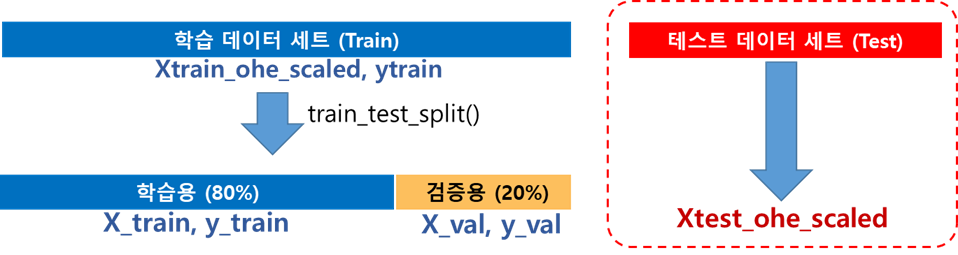

In [ ]:
#선택된 모델로 예측하기 - 하이퍼 파라미터 튜닝 안할때
pred_test = <blank>.predict(Xtest_ohe_scaled)

#선택된 모델로 예측하기 - 하이퍼 파라미터 튜닝 할때
#pred_test = grid_search.<blank>.predict(Xtest_ohe_scaled)

pred_test

### (2) 실제값과 예측값의 분포 비교

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(8,3))
sns.<blnak>(x=ytrain, ax=axs[0])
sns.countplot(x=pred_test, ax=axs[1])

## [step6] 결과 파일 생성 
### (1) 예시 파일 불러오기 

In [ ]:
#예시 파일 불러오기
submission = pd.<blank>('./sample_submission.csv')
submission.head(5)

### (2) 예측 결과 저장

In [ ]:
#test data의 예측 결과 저장하기
submission['Class'] = <blank>
submission.head(5)

### (3) 제출할 csv파일 생성

In [ ]:
#제출 파일 생성하기
submission.<blank>('./submission.csv', index=False)

**수고하셨습니다** 